<a href="https://colab.research.google.com/github/nguyenxuandinhit/TH_Deep_Learning/blob/main/Deep_Tuan4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, Dense, MaxPool2D, Flatten, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print('TensorFlow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# ============================================================
# BÀI 1: CIFAR-10
# ============================================================

# 1. Nạp dữ liệu CIFAR-10
(X_train_cf, y_train_cf), (X_test_cf, y_test_cf) = keras.datasets.cifar10.load_data()

CLASS_NAMES_CIFAR = ['airplane','automobile','bird','cat','deer',
                     'dog','frog','horse','ship','truck']
NUM_CLASSES = 10

print('X_train shape:', X_train_cf.shape)  # (50000, 32, 32, 3)
print('X_test shape :', X_test_cf.shape)   # (10000, 32, 32, 3)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
X_train shape: (50000, 32, 32, 3)
X_test shape : (10000, 32, 32, 3)


/tmp/ipykernel_391/462781401.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title(CLASS_NAMES_CIFAR[int(y_train_cf[i])], fontsize=11)


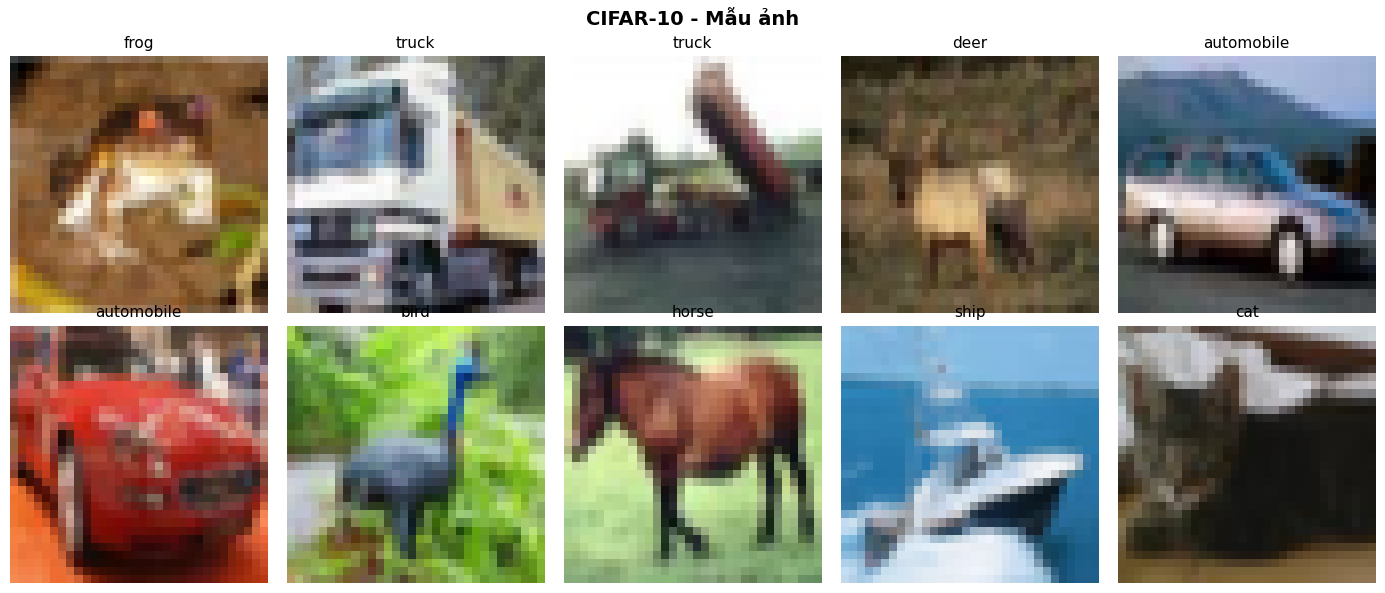

In [5]:
# 2. Trực quan hóa một số ảnh mẫu
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_train_cf[i])
    ax.set_title(CLASS_NAMES_CIFAR[int(y_train_cf[i])], fontsize=11)
    ax.axis('off')
plt.suptitle('CIFAR-10 - Mẫu ảnh', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# 3. Tiền xử lý dữ liệu
X_train_cf = X_train_cf.astype('float32') / 255.0
X_test_cf  = X_test_cf.astype('float32') / 255.0

y_train_cf_cat = keras.utils.to_categorical(y_train_cf, NUM_CLASSES)
y_test_cf_cat  = keras.utils.to_categorical(y_test_cf,  NUM_CLASSES)

In [7]:
# 4. Xây dựng mô hình CNN cho CIFAR-10
def build_cifar_model():
    model = Sequential([
        Input(shape=(32, 32, 3)),

        # Block 1
        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        MaxPool2D(pool_size=(2,2)),
        Dropout(0.25),

        # Block 2
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        MaxPool2D(pool_size=(2,2)),
        Dropout(0.25),

        # Block 3
        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPool2D(pool_size=(2,2)),
        Dropout(0.25),

        # Fully connected
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

model_cf = build_cifar_model()
model_cf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,434 (2.55 MB)

 Trainable params: 666,986 (2.54 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# 5. Compile & Huấn luyện
model_cf.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_cf = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6)
]

history_cf = model_cf.fit(
    X_train_cf, y_train_cf_cat,
    batch_size=64,
    epochs=30,
    validation_split=0.1,
    callbacks=callbacks_cf,
    verbose=1
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.3729 - loss: 1.7354 - val_accuracy: 0.4992 - val_loss: 1.4451 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5165 - loss: 1.3412 - val_accuracy: 0.5688 - val_loss: 1.3083 - learning_rate: 0.0010
Epoch 3/30
269/704 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5649 - loss: 1.2186

In [ ]:
# 6. Đánh giá & Vẽ biểu đồ
score_cf = model_cf.evaluate(X_test_cf, y_test_cf_cat, verbose=0)
print(f'[CIFAR-10] Test Loss    : {score_cf[0]:.4f}')
print(f'[CIFAR-10] Test Accuracy: {score_cf[1]*100:.2f}%')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_cf.history['accuracy'],     label='Train')
ax1.plot(history_cf.history['val_accuracy'], label='Val')
ax1.set_title('CIFAR-10 - Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(history_cf.history['loss'],     label='Train')
ax2.plot(history_cf.history['val_loss'], label='Val')
ax2.set_title('CIFAR-10 - Loss'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout(); plt.show()

In [ ]:
# 7. Dự báo một số ảnh test
predictions_cf = model_cf.predict(X_test_cf[:10])

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_test_cf[i])
    pred_label  = CLASS_NAMES_CIFAR[np.argmax(predictions_cf[i])]
    true_label  = CLASS_NAMES_CIFAR[int(y_test_cf[i])]
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f'Pred: {pred_label}\nTrue: {true_label}', color=color, fontsize=9)
    ax.axis('off')
plt.suptitle('CIFAR-10 - Kết quả dự báo', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# BÀI 2: CAT vs DOG
# Dùng tensorflow_datasets (không cần tải file thủ công)
# ============================================================

# Nếu giảng viên cung cấp dữ liệu theo thư mục:
# train/
#   cats/  *.jpg
#   dogs/  *.jpg
# test/
#   cats/  *.jpg
#   dogs/  *.jpg
#
# Thay TRAIN_DIR và TEST_DIR phía dưới bằng đường dẫn thực tế
# Ví dụ: TRAIN_DIR = '/content/drive/MyDrive/catdog/train'

USE_TFDS = True  # Đặt False nếu dùng dữ liệu giảng viên cung cấp

IMG_SIZE_CD = (128, 128)
BATCH_SIZE  = 32

if USE_TFDS:
    import tensorflow_datasets as tfds

    (ds_train_cd, ds_test_cd), ds_info = tfds.load(
        'cats_vs_dogs',
        split=['train[:80%]', 'train[80%:]'],
        as_supervised=True,
        with_info=True
    )

    def preprocess_cd(image, label):
        image = tf.image.resize(image, IMG_SIZE_CD)
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    ds_train_cd = ds_train_cd.map(preprocess_cd).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    ds_test_cd  = ds_test_cd.map(preprocess_cd).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    CLASS_NAMES_CD = ['Cat', 'Dog']
    print('Dataset Cats vs Dogs đã nạp xong!')

else:
    # === Dùng dữ liệu giảng viên cung cấp ===
    TRAIN_DIR = '/content/catdog/train'  # <-- Thay đường dẫn tại đây
    TEST_DIR  = '/content/catdog/test'   # <-- Thay đường dẫn tại đây

    from tensorflow.keras.preprocessing.image import ImageDataGenerator

    train_gen = ImageDataGenerator(rescale=1./255, rotation_range=20,
                                   width_shift_range=0.1, height_shift_range=0.1,
                                   horizontal_flip=True)
    test_gen  = ImageDataGenerator(rescale=1./255)

    ds_train_cd = train_gen.flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE_CD,
                                                batch_size=BATCH_SIZE, class_mode='binary')
    ds_test_cd  = test_gen.flow_from_directory(TEST_DIR,   target_size=IMG_SIZE_CD,
                                                batch_size=BATCH_SIZE, class_mode='binary')
    CLASS_NAMES_CD = list(ds_train_cd.class_indices.keys())
    print('Classes:', CLASS_NAMES_CD)

In [ ]:
# Xây dựng mô hình CNN cho Cat vs Dog
def build_catdog_model():
    model = Sequential([
        Input(shape=(*IMG_SIZE_CD, 3)),

        Conv2D(32, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPool2D(2,2),
        Dropout(0.25),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPool2D(2,2),
        Dropout(0.25),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPool2D(2,2),
        Dropout(0.25),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')  # Binary: cat=0, dog=1
    ])
    return model

model_cd = build_catdog_model()
model_cd.summary()

In [ ]:
# Compile & Huấn luyện Cat vs Dog
model_cd.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks_cd = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=3)
]

history_cd = model_cd.fit(
    ds_train_cd,
    epochs=20,
    validation_data=ds_test_cd,
    callbacks=callbacks_cd,
    verbose=1
)

In [ ]:
# Đánh giá & vẽ biểu đồ Cat vs Dog
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_cd.history['accuracy'],     label='Train')
ax1.plot(history_cd.history['val_accuracy'], label='Val')
ax1.set_title('Cat vs Dog - Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(history_cd.history['loss'],     label='Train')
ax2.plot(history_cd.history['val_loss'], label='Val')
ax2.set_title('Cat vs Dog - Loss'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# BÀI 3: FASHION-MNIST
# ============================================================

CLASS_NAMES_FM = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
                  'Sandal','Shirt','Sneaker','Bag','Ankle boot']

# Nạp dữ liệu (có sẵn trong Keras)
(X_train_fm, y_train_fm), (X_test_fm, y_test_fm) = keras.datasets.fashion_mnist.load_data()

# Tiền xử lý
X_train_fm = X_train_fm.astype('float32') / 255.0
X_test_fm  = X_test_fm.astype('float32') / 255.0
X_train_fm = X_train_fm.reshape(-1, 28, 28, 1)
X_test_fm  = X_test_fm.reshape(-1, 28, 28, 1)

y_train_fm_cat = keras.utils.to_categorical(y_train_fm, 10)
y_test_fm_cat  = keras.utils.to_categorical(y_test_fm,  10)

print('X_train shape:', X_train_fm.shape)

# Trực quan hóa
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_train_fm[i].reshape(28,28), cmap='gray')
    ax.set_title(CLASS_NAMES_FM[y_train_fm[i]], fontsize=9)
    ax.axis('off')
plt.suptitle('Fashion-MNIST - Mẫu ảnh', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# Xây dựng & huấn luyện CNN cho Fashion-MNIST
model_fm = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model_fm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fm.summary()

history_fm = model_fm.fit(
    X_train_fm, y_train_fm_cat,
    batch_size=128,
    epochs=20,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

In [ ]:
# Đánh giá Fashion-MNIST
score_fm = model_fm.evaluate(X_test_fm, y_test_fm_cat, verbose=0)
print(f'[Fashion-MNIST] Test Loss    : {score_fm[0]:.4f}')
print(f'[Fashion-MNIST] Test Accuracy: {score_fm[1]*100:.2f}%')

# Dự báo và hiển thị
preds_fm = model_fm.predict(X_test_fm[:10])
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_test_fm[i].reshape(28,28), cmap='gray')
    pred  = CLASS_NAMES_FM[np.argmax(preds_fm[i])]
    true  = CLASS_NAMES_FM[y_test_fm[i]]
    color = 'green' if pred == true else 'red'
    ax.set_title(f'P:{pred}\nT:{true}', color=color, fontsize=8)
    ax.axis('off')
plt.suptitle('Fashion-MNIST - Kết quả dự báo', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Vẽ accuracy/loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_fm.history['accuracy'],     label='Train')
ax1.plot(history_fm.history['val_accuracy'], label='Val')
ax1.set_title('Fashion-MNIST - Accuracy'); ax1.legend()
ax2.plot(history_fm.history['loss'],     label='Train')
ax2.plot(history_fm.history['val_loss'], label='Val')
ax2.set_title('Fashion-MNIST - Loss'); ax2.legend()
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# BÀI 4: NHẬN DẠNG GIỚI TÍNH (Nam / Nữ)
# ============================================================

# ===== OPTION A: Dùng dữ liệu giảng viên cung cấp =====
# Cấu trúc thư mục cần có:
# /content/gender/train/male/   *.jpg
# /content/gender/train/female/ *.jpg
# /content/gender/test/male/    *.jpg
# /content/gender/test/female/  *.jpg

USE_TEACHER_DATA = False  # Đặt True nếu có dữ liệu giảng viên

IMG_SIZE_GEN = (64, 64)
BATCH_SIZE_GEN = 32

if USE_TEACHER_DATA:
    from tensorflow.keras.preprocessing.image import ImageDataGenerator

    TRAIN_DIR_GEN = '/content/gender/train'  # <-- Sửa đường dẫn
    TEST_DIR_GEN  = '/content/gender/test'   # <-- Sửa đường dẫn

    train_gen_g = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        horizontal_flip=True,
        zoom_range=0.1
    )
    test_gen_g = ImageDataGenerator(rescale=1./255)

    ds_train_gen = train_gen_g.flow_from_directory(
        TRAIN_DIR_GEN, target_size=IMG_SIZE_GEN,
        batch_size=BATCH_SIZE_GEN, class_mode='binary'
    )
    ds_test_gen = test_gen_g.flow_from_directory(
        TEST_DIR_GEN, target_size=IMG_SIZE_GEN,
        batch_size=BATCH_SIZE_GEN, class_mode='binary'
    )
    print('Classes:', ds_train_gen.class_indices)

else:
    # ===== OPTION B: Dùng CelebA (tensorflow_datasets) =====
    # Thuộc tính 'Male' làm nhãn giới tính
    import tensorflow_datasets as tfds

    ds_celeba, info_celeba = tfds.load(
        'celeb_a',
        split=['train', 'test'],
        with_info=True,
        as_supervised=False
    )

    def preprocess_celeba(example):
        img   = tf.image.resize(example['image'], IMG_SIZE_GEN)
        img   = tf.cast(img, tf.float32) / 255.0
        label = tf.cast(example['attributes']['Male'], tf.int32)
        return img, label

    ds_train_gen = ds_celeba[0].map(preprocess_celeba).shuffle(2000).batch(BATCH_SIZE_GEN).prefetch(tf.data.AUTOTUNE)
    ds_test_gen  = ds_celeba[1].map(preprocess_celeba).batch(BATCH_SIZE_GEN).prefetch(tf.data.AUTOTUNE)
    print('CelebA loaded! Label: 0=Female, 1=Male')

In [ ]:
# Xây dựng CNN cho bài toán giới tính
model_gen = Sequential([
    Input(shape=(*IMG_SIZE_GEN, 3)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # 0=Female, 1=Male
])

model_gen.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model_gen.summary()

In [ ]:
# Huấn luyện mô hình giới tính
history_gen = model_gen.fit(
    ds_train_gen,
    epochs=15,
    validation_data=ds_test_gen,
    callbacks=[
        EarlyStopping(patience=4, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.5, patience=2)
    ],
    verbose=1
)

# Vẽ biểu đồ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_gen.history['accuracy'],     label='Train')
ax1.plot(history_gen.history['val_accuracy'], label='Val')
ax1.set_title('Gender - Accuracy'); ax1.legend()
ax2.plot(history_gen.history['loss'],     label='Train')
ax2.plot(history_gen.history['val_loss'], label='Val')
ax2.set_title('Gender - Loss'); ax2.legend()
plt.tight_layout(); plt.show()